<div style="text-align: center; font-size: 30px;">
Statistics Labs<br/>
</div>
<div style="text-align: center; font-size: 30px;">
Probability papers
</div>
<div style="text-align: center; font-size: 16px; font-style: italic">
Material prepared by M. Dolores Frías, Jesús Fernández, and Carmen M. Sordo, senior lectures from the Department of Applied Mathematics and Computer Science at the University of Cantabria.
</div>

# Objectives

Graphical methods have traditionally been used in engineering due to their simplicity and useful
for analyzing data and understanding its structure. With the popularization of computers as a usual
work tool, the graphic representation has gone from being done manually to be done on the computer.
One of the traditional graphical methods that can be easily implemented in R is the one based on the
probability paper concept.

The basic idea of probability paper of a two-parameter family of distributions is to modify the
scales of the axes for the random variable and for the accumulated probability, in such a way that this
family becomes a family of straight lines. In this way, when the CDF is plotted in that paper, the aspect
of the graph (straight line or not) is used to decide if the data come from that family of distributions
or not. In addition, the parameters of the particular distribution that best fits can be obtained from
the representation.

# Empirical cumulative distribution function (ECDF)

If we take a sample from a population whose distribution function we do not know, we can construct a *sample distribution function* known as the **empirical distribution function** (ECDF). This function will give us the probability of obtaining a value less than or equal to one given from the
obtained sample. To build it, we order the values $x_i$ that the variable has
taken in our sample of size $n$. The element that occupies the i-th place once
sorted the sample is known as a **statistic of order** $i$, and we will
denote it by $x_{i:n}$. 

The ECDF assigns to each value obtained in the sample a cumulative probability $i/n$:

$S_n(x_{i:n})= \frac{i}{n}$

Actually, this function is defined on the entire real line and shows jumps. In R, it can be obtained using the function `ecdf`:

[1] 0.92

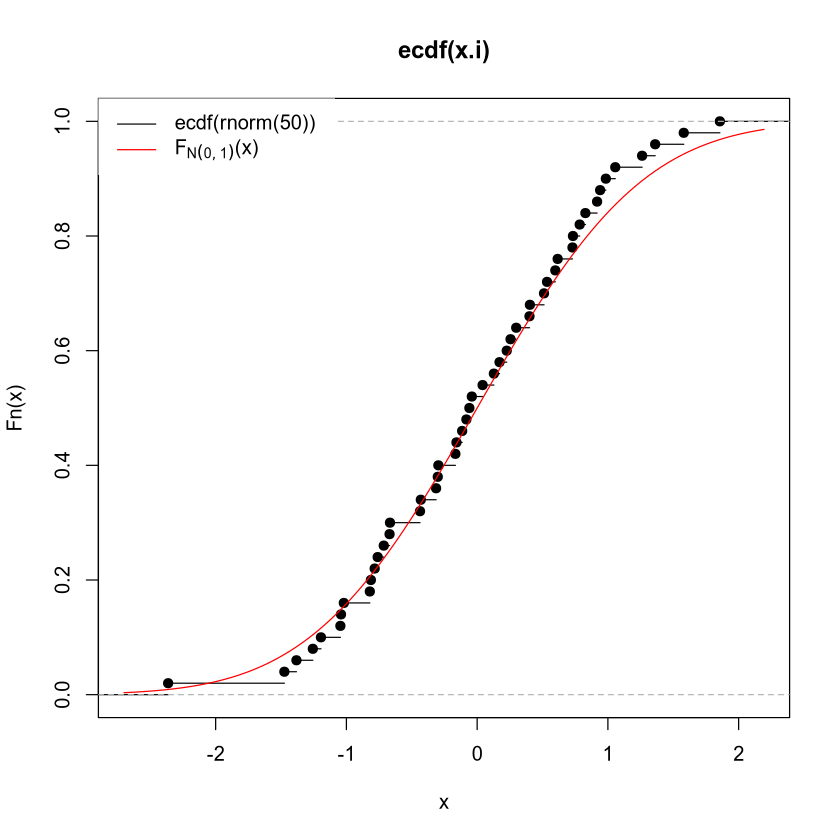

In [2]:
x.i <- rnorm(50)       # Sample os size 50 from N(0,1)
Sn <- ecdf(x.i)        # ECDF
Sn(1.2)                # We can use it as a function...
plot(Sn)               # ... plot consider it in a particular way
curve(pnorm(x), col="red", add=T)  # We can compare it with the distribution from the original population
legend("topleft", legend=c("ecdf(rnorm(50))", expression("F"[N(0,1)]*"(x)")),
       col=c("black","red"), lty=1, box.lty=0)

This empirical cumulative distribution function is the one we want to represent
on the probability paper that is, in a graph with new scales on the axes, in
such a way that its points are forming a straight line instead of the curve ploted above. 

However, in the case of many families of
distributions, the value $1$ (which reaches $S_n(x_{n:n})$), when the scale
transformation is applied become $\infty $. Therefore, it is impossible to draw
it. One solution to this problem is to use other plotting positions different
from $i/n$ to assign the cumulative probability up to each sample data. The
following table summarizes different formulas to obtain plotting positions
proposed by different authors:




<div><img alt="Plotting positions" src="./figuras/tabla_punteo_en.png" width="250"/></div>

In what follows we will use Hazen's formula, although in R we can use any other without much difficulty. 

For the development of this practice we have programmed a series of functions contained in the file *papeles.R* which, among others, also includes functions to calculate these scores as:

In [8]:
source("functions/papeles.R")    # Load the file with the functions for this practice
punteo.hazen(50)       # Return the probabilities assigned by Hazen's formula to a sample of size 50

[1] 0.01 0.03 0.05 0.07 0.09 0.11 0.13 0.15 0.17 0.19 0.21 0.23 0.25 0.27 0.29
[16] 0.31 0.33 0.35 0.37 0.39 0.41 0.43 0.45 0.47 0.49 0.51 0.53 0.55 0.57 0.59
[31] 0.61 0.63 0.65 0.67 0.69 0.71 0.73 0.75 0.77 0.79 0.81 0.83 0.85 0.87 0.89
[46] 0.91 0.93 0.95 0.97 0.99

Remember that for using all the functions programmed in *papeles.R* in your RStudio session, you should run the `source("papeles.R")` command only once at the beginning of the script. Then all the functions we need will be loaded. Also, for this command to work, we must have established the working directory that contains the file *papeles.R* with the command `setwd()`.

In [9]:
punteo.gringorten(50) # With Gringorten formula

[1] 0.01117318 0.03112530 0.05107741 0.07102953 0.09098164 0.11093376
 [7] 0.13088587 0.15083799 0.17079010 0.19074222 0.21069433 0.23064645
[13] 0.25059856 0.27055068 0.29050279 0.31045491 0.33040702 0.35035914
[19] 0.37031125 0.39026337 0.41021548 0.43016760 0.45011971 0.47007183
[25] 0.49002394 0.50997606 0.52992817 0.54988029 0.56983240 0.58978452
[31] 0.60973663 0.62968875 0.64964086 0.66959298 0.68954509 0.70949721
[37] 0.72944932 0.74940144 0.76935355 0.78930567 0.80925778 0.82920990
[43] 0.84916201 0.86911413 0.88906624 0.90901836 0.92897047 0.94892259
[49] 0.96887470 0.98882682

R also has a generic function `ppoints(n,a)` that implements the formula $p_{i:n}=\frac{i-a}{n+(1-2a)}$ that allows calculating these and other plotting positions depending on the value of a. For example, the two cases above can be obtained as `ppoints(50,0.5)` (Hazen) and `ppoints(50,0.44)` (Gringorten).

# Basics of the probability paper

The probability paper is simply a paper in which the scales have been
modified in such a way that the distribution functions of a certain family,
when drawn in it become a family of straight lines.

Given $F_X(x;\theta_1,\theta_2)$ a two-parameter family of distributions, where $\theta_1$ and $\theta_2$ are the parameters, we look for a transformation \begin{equation}
\xi =g(x)\quad;\quad \eta =h(y)\quad \quad \quad (1)
\end{equation}
such that the family of curves
\begin{equation}
y=F_X(x;\theta_1,\theta_2)\quad \quad \quad (2)
\end{equation}
when they transform by (1) become in a family of straight lines:
\begin{equation}
h(y)=h[F_X(x;\theta_1,\theta_2)]=ag(x)+b\quad \quad \Leftrightarrow \quad \quad \eta
=a\xi +b  \quad \quad \quad (3)
\end{equation}
where the variable $\eta $ is called the reduced variable and $a=a(\theta_1,\theta_2)$ and $b=b(\theta_1,\theta_2)$ are, respectively, the slope and the intercept of the line to which $F_X(x;\theta_1,\theta_2)$ becomes.

Therefore, for there to be a probability paper associated with a certain
family of distribution functions $F_X(x;\theta_1,\theta_2)$ requires that
\begin{equation}
F_X(x;\theta_1,\theta_2)=h^{-1}[ag(x)+b]\quad \quad \quad (4)
\end{equation}

Given a known family of distributions, we will have to find the form of the $h$
and $g$ transformations that make the probability paper possible for that
family. In this practice we will refresh one of the transformations seen in
class that makes normal paper possible and we will analyze in detail the
necessary transformation of exponential paper. In addition to these two roles,
we will also use the rest of the probability papers whose transformations we
have seen in class.



# Normal probability paper plot

If $F_X(x;\mu , \sigma )$ is the CDF of the Normal variable, it can be written as:
\begin{equation}
F_X(x;\mu , \sigma )=\Phi \left({{x-\mu } \over \sigma }\right)\quad \quad \quad (5)  
\end{equation}
where $\mu $ and $\sigma $ are the mean and the standard deviation respectively, and $\Phi (x)$ is the CDF of the standard Normal distribution $F_{N(0,1)}(x)$.

Then, according to (1) and (3), the equation (5) is:
\begin{equation}
\xi =g(x)=x\quad;\quad\eta =h(y)=\Phi ^{-1}(y)\quad;\quad a={1 \over \sigma
}\quad;\quad b=-\frac{\mu}{\sigma}\quad \quad \quad (6) 
\end{equation}
and the family of straight lines becomes
\begin{equation}
\eta =a\xi +b={{\xi -\mu } \over \sigma } \quad \quad \quad (7) 
\end{equation}

If the points $\left( g(x_{i:n}), h\!\left(\frac{i-0.5}{n}\right) \right) = \left(x_{i:n}, \Phi^{-1}\!\left(\frac{i-0.5}{n}\right) \right)$ line up forming a straight line, the hypotesis of normality is accepted and the estimation of the parameteres $\mu $ and $\sigma $ is possible by fitting a line to themselves. Note that if $\eta =0$ and $\eta =1$ in (7) the result is:
\begin{equation} \begin{array}{l}\eta =0\quad\Rightarrow \quad 0={{\xi -\mu }
\over \sigma }\quad\Rightarrow \quad\xi_{\eta =0} =\mu \\
  \eta =1\quad \Rightarrow \quad 1={{\xi -\mu } \over \sigma }\quad\Rightarrow\quad \xi_{\eta =1} =\mu +\sigma
\end{array} \end{equation}

Next Figure shows a normal probability paper, where the axis of the ordinates has been transformed by $\eta =\Phi ^{-1}(y)$ and the axis of abscissas has no transformation. In this paper the points of the empirical distribution function are plotted directly: $\left( x_{i:n}, \frac{i-0.5}{n}\right)$.

<div><img alt="papel_normal" src="./figuras/papel_normal.png" width="500"/></div>

*Normal probability paper representing data from a sample of size 50 taken from a standardized Normal distribution.* 

## Normal probability paper in R

In R you can easily draw the necessary data transformations to represent a
set of data on Normal probability paper. To do this, just use the function
`qnorm` like $h(y)$ to transform the empirical probabilities. 

However, in the instructions of the file *papeles.R* it is defined a function
`papel.normal` that facilitates the representation. To use it just run:

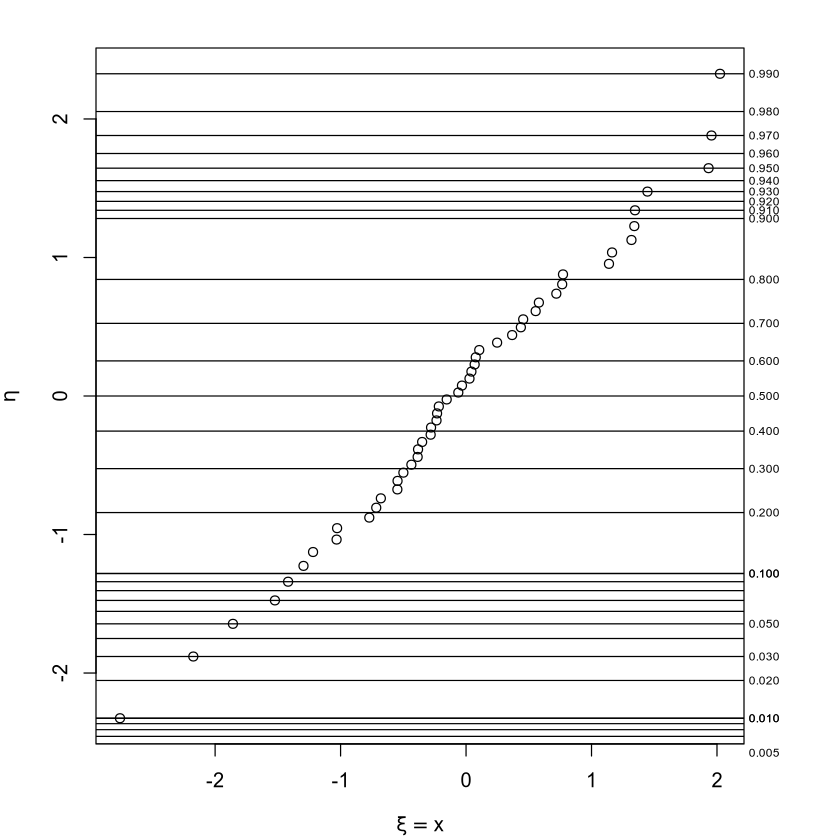

In [10]:
load("data/normal.rda")  # load the variable named data
papel.normal(data)

We observe that the points align to form a straight line. This confirms that the sample comes from a Normal distribution. Then, we proceed to obtain the line that best fits the data using least squares with the argument `show.fit`. As we can see, we obtain in the graph the value of $\xi_{\eta=0}=\mu=-0.04$ and $\xi_{\eta=1}=\mu+\sigma= 1.01$, from which we can obtain the value of the parameters $\mu=-0.045$ and $\sigma=1.054$:


$mean
[1] -0.0444501

$sd
[1] 1.054324

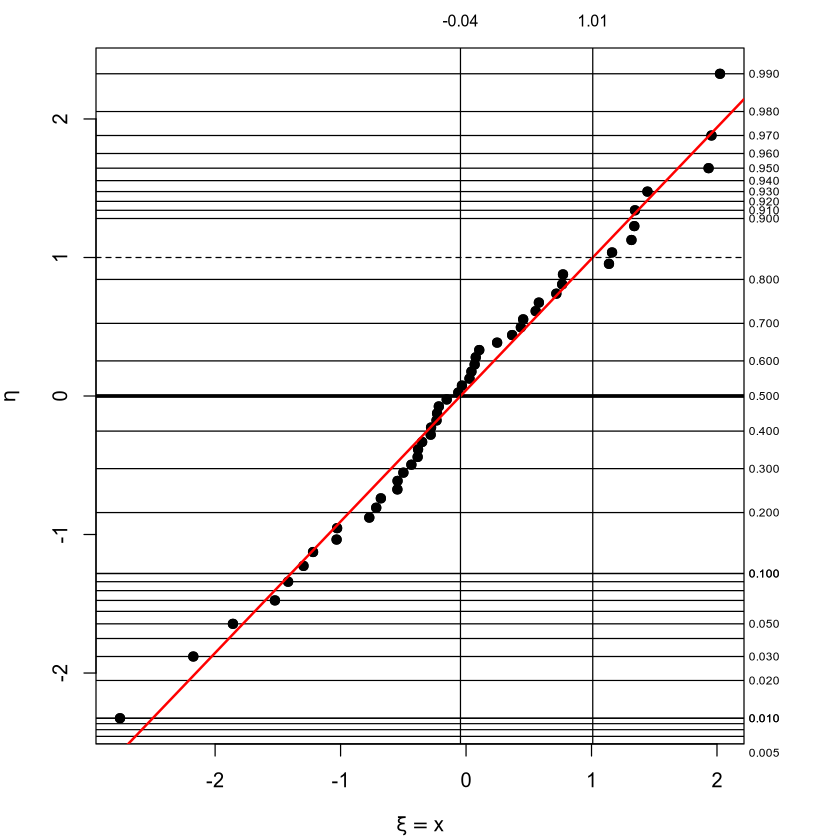

In [6]:
papel.normal(data, show.fit=TRUE)

Note that the output of that function returns the previous values of $\mu$ *(mean)*  and $sigma$ *(sd)*. These two values can be save in a variable to be used later for any other calculation. For instance to compute a probability as in the following example where we obtain that P(X<=2)=0.97:

[1] 0.973756

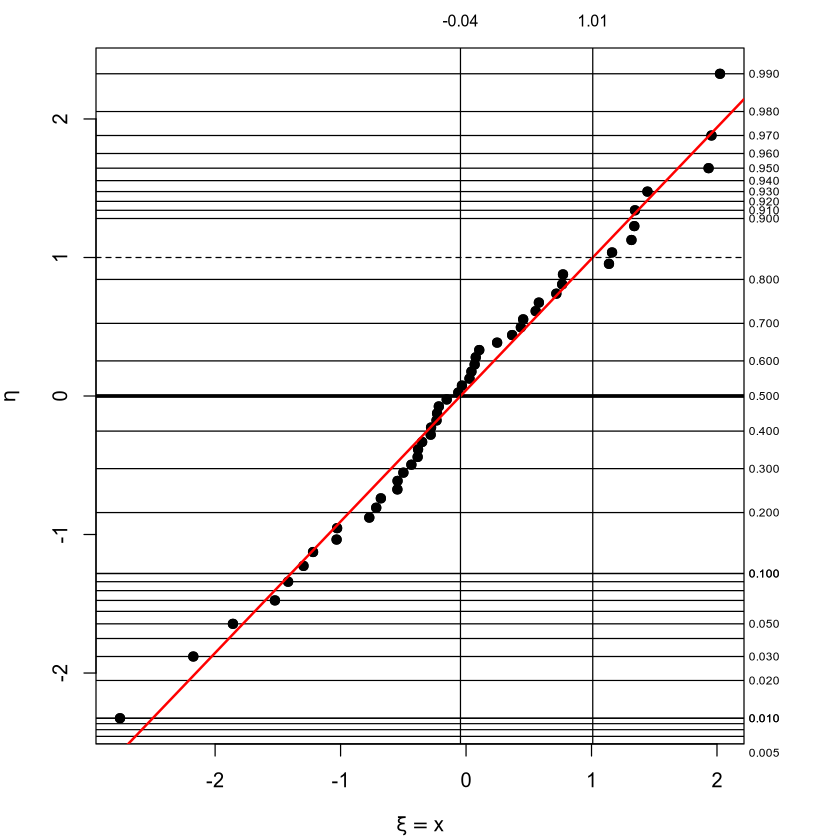

In [11]:
papelnorm_out <- papel.normal(data, show.fit=TRUE)
# P(X<=2) 
pnorm(2, papelnorm_out$mean, papelnorm_out$sd)

Often the most extreme data in a sample do not fit a line well. This is because the regions with low probability of occurrence (the tails of the distribution) need very large sample sizes to have a sufficient number of data to adequately be represented. It is common to miss values in ranges that had a small probability of occurring and to appear values in other more unlikely ranges. For this reason, it is sometimes preferable to discard the most extreme data in the sample and fit the line only to the values that actually line up. The `papel.normal` function takes the argument `trim=N`, to remove `N` points from each tail before making the linear fit. 

Try this with the previous data and observe the effect on the line and the different values of the parameters of the Normal distribution:

$mean
[1] -0.03058498

$sd
[1] 1.019299

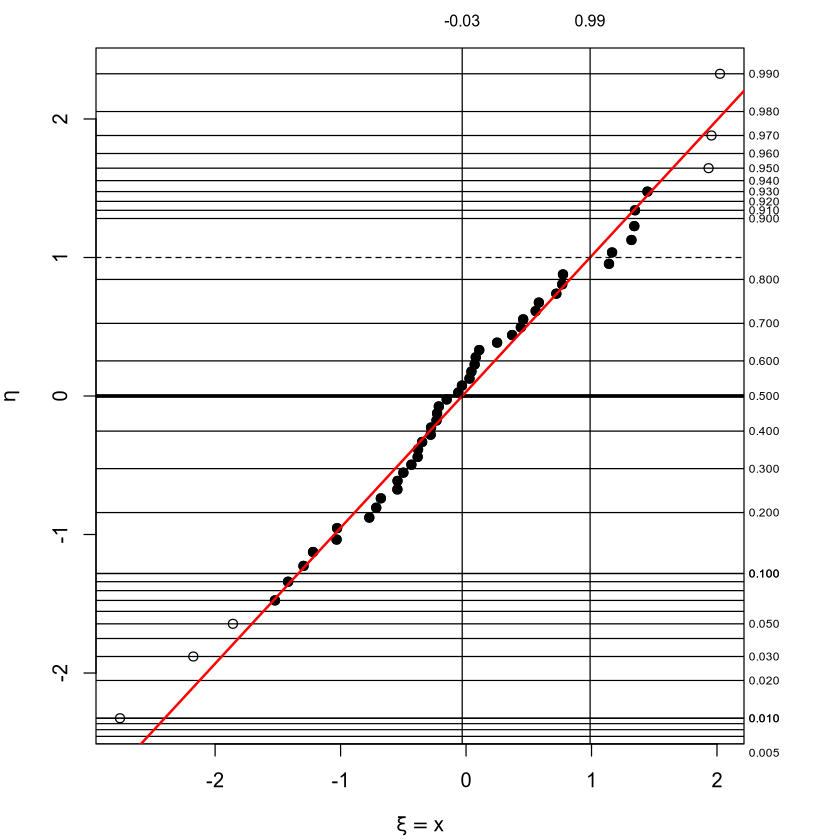

In [12]:
papel.normal(data, show.fit=TRUE, trim=3)

<div class="alert alert-block alert-info">
<strong>PRACTICE ON YOUR OWN</strong>

- The file *resistencias.rda* contains compressive strength data (in Kg/cm$^2$) of 40 concrete specimens.
  1. Check if the hypothesis that the resistances are normally distributed can be accepted.
  2. Get the mean strength and standard deviation from the fitted normal model.
  3. If the characteristic resistance is defined as that which is exceeded by 95\% of the samples and we consider the previous adjustment to be good, what is the characteristic resistance of this concrete? Look at the graph obtained above and identify that value on the graph itself.

</n>

- The file *datos_papeles.rda* contains 4 samples of 30 data each. When loading the file, they are available in the variables: data1, data2, data3 and data4. Plot the samples on normal probability paper and, if this model is acceptable, obtain the distribution parameters. 


</div>

# Exponencial probability paper

The exponential probability paper transforms the exponential distribution function into a straight line. We are going to generalize the exponential random variable with respect to the one we have seen in theory, adding a location parameter $x_0$, that is:

$F_{Ex(\alpha,x_0)}(x) = 1- e^{-\alpha(x-x_0)} \qquad \forall x \ge x_0$

This distribution is known as the shifted exponential distribution. Making $x_0=0$ returns the ordinary exponential distribution. 

If we make the transformations:

$\eta = h(y) = -\ln(1-y) \qquad \xi=g(x) = x$

we can write the shifted exponential as:

$y = 1- e^{-\alpha(x-x_0)}
\;\Rightarrow\; \eta = h(y) = -\ln(1-y) = \alpha(x-x_0) = \alpha(\xi -x_0)$

namely

$\eta = a\xi +b$

with $a=\alpha$ and $b=-\alpha x_0$.

Again, the cuts with the lines $\eta=0$ and $\eta=1$, allow us to obtain the parameters of the distribution:
\begin{eqnarray}
\eta = 0 & \;\Rightarrow\; & 0 = \alpha(\xi -x_0) \;\Rightarrow\; \xi_{\eta=0} = x_0 \\
\eta = 1 & \;\Rightarrow\; & 1 = \alpha(\xi -x_0) \;\Rightarrow\; \xi_{\eta=1} = x_0+\alpha^{-1}
\end{eqnarray}


## Exponential probability paper in R

The file *papeles.R* includes the function `papel.exponencial` to
easily draw the necessary data transformations to represent a set of data on
the exponential probability paper. To do this, just run:

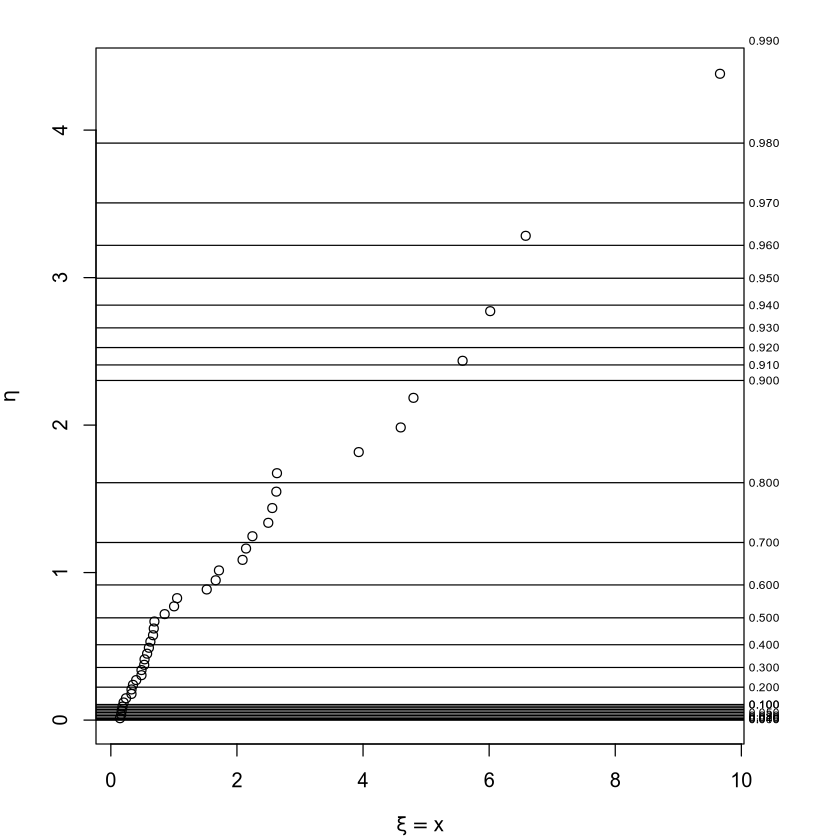

In [14]:
data <- rexp(40, 0.5)  # get 40 ramdom data from an Ex(0.5)
papel.exponencial(data)

The sample of 40 data points fits a straight line quite well, confirming that it comes from an exponential distribution, something we already knew, since the data were generated using the *rexp()* function. Therefore, we can now fit a linear regression line to this set of points. As in the case of the function for the normal probability paper, *papel.exponencial* also takes the arguments `show.fit` and `trim`. In adition, it has the argument `allow.shift=FALSE`, which sets the unshifted version of the exponential distribution (ie, forces $x_0=0$).

Fit the model and obtain the parameters of the exponential distribution.

<div class="alert alert-block alert-info">
<strong>PRACTICE ON YOUR OWN</strong>

Check if any of the samples in the file *datos_papeles.rda* responds to an exponential distribution and, in such a case, obtain its parameters.
</div>

# Extreme probability paper

In this section we will deal with the use of the probability paper for the
extreme case. Therefore, we will focus on analyzing the tails of the
distribution (right or left according to interest) since this is the only
part of the distribution function that governs the behavior of extremes,
either maxima or minima.

As an example we will consider the Normal and Exponential distributions to
illustrate the role of queues in the extreme behavior. To this end, we are
going to use some of the functions contained in the file *papeles.R* to
represent samples of these two common distributions in maximal and minimal
Gumbel probability paper. Then we will analyze in each case the domain of
attraction of the extremes. 

We will use the file *distribuciones.rda* which contains data from a distribution $N(\mu=6, \sigma=2)$ and $Exp(\alpha=0.2)$.

The following objects are masked from distribuciones (pos = 3):

    exp, normal




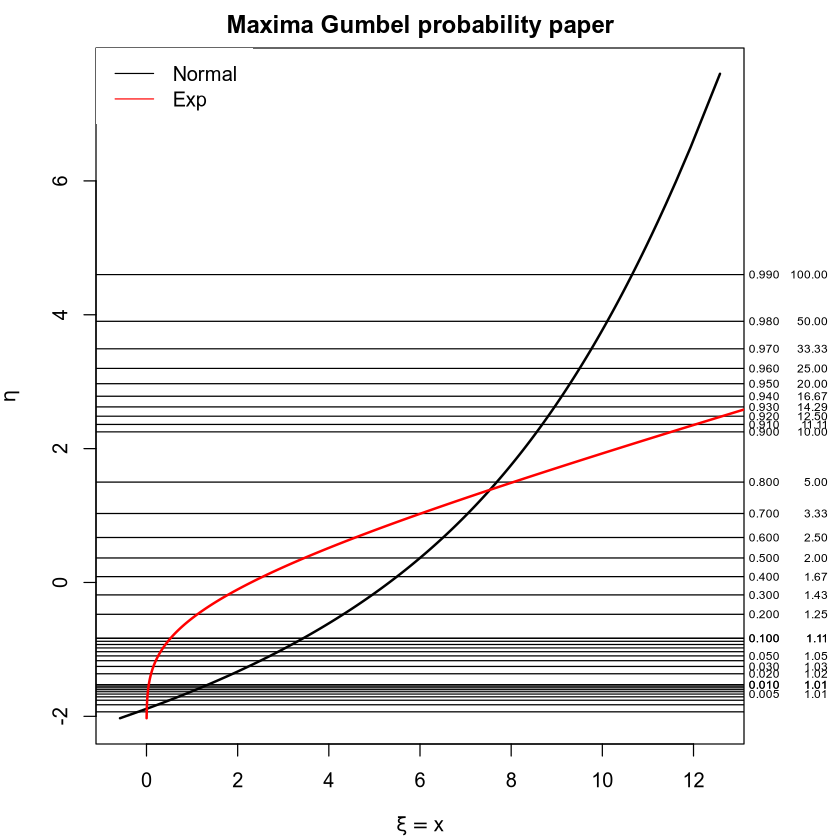

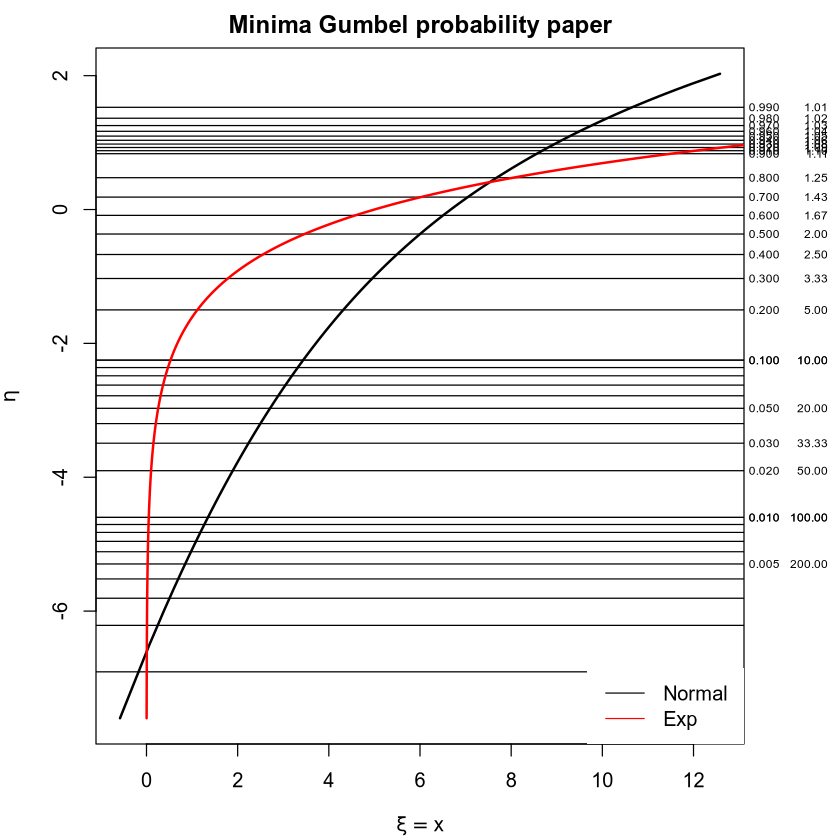

In [16]:
# Load the data 
load("data/distribuciones.rda")
attach(distribuciones)
# Maxima Gumbel probability paper
papel.maximal(normal, x.transform="gumbel", type="l", lwd=2)
title("Maxima Gumbel probability paper")
papel.maximal.lines(exp, col="red", lwd=2)
legend("topleft", legend=c("Normal", "Exp"),
       col=c("black","red"), lty=1, box.lty=0, bg="white")
# Minima Gumbel probability paper
papel.minimal(normal, x.transform="gumbel", type="l", lwd=2)
title("Minima Gumbel probability paper")
papel.minimal.lines(exp, col="red", lwd=2)
legend("bottomright", legend=c("Normal", "Exp"),
       col=c("black","red"), lty=1, box.lty=0, bg="white")


In this case we have used the functions `papel.maximal.lines`
and `papel.minimal.lines` from the file `papeles.R` which allow us to
add the representation of another sample to the graph of the maximal or
mininal probability paper plot already created. Furthermore, we have used
the argument `type="l"` that you already know since most of the plotting
functions admit it, in order to join the data with a line instead of
plotting the values with points.

The representation of these two distributions in the maximal Gumbel probability
paper, shows a linearity of the right tail in both distributions, which confirms that both distributions belong to the Gumbel domain of attraction for maxima. 

The same distributions are represented in the minimal Gumbel probability paper. It is
observed the linearity of the left tail of the Normal distribution, indicating
thus that it belongs to the Gumbel domain of attraction for minima. In the case
of the exponential distribution, a vertical slope is observed when approaching
to the lower limits. This suggests a Weibull domain of attraction for minima.

The analysis of both distributions confirms the attraction domains of the
extremes that we had already obtained in class for these two distributions.


<div class="alert alert-block alert-info">
<strong>PRACTICE ON YOUR OWN</strong>

- The file *T1007_phone_calls.txt* contains the times in seconds between $36$ consecutive calls made in an automatic telephone exchange (Castillo and Pruneda, 2001).
  1. Load this data into R.
  2. Plot these data on a exponential probability paper. Can we say that the occurrence of calls to this switchboard follows a homogeneous Poisson process?
  3. Obtain the rate of occurrence of calls in the switchboard.
  4. Determine the probability that the wait time to receive a call is at most 5 milliseconds.
  5. Estimate the domain of attraction for minima and maxima.
  
</div>